In [1]:
#cell 1 setup
import multiprocessing
multiprocessing.set_start_method("spawn",force=True)
import os
import random
import gc
import json
import re
#env vars
os.environ["HF_DATASETS_DISABLE_PROGRESS_BARS"]="1"
os.environ["TOKENIZERS_PARALLELISM"]="false"
os.environ["OMP_NUM_THREADS"]="1"
os.environ["MKL_NUM_THREADS"]="1"
os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"]="1"
CACHE_DIR=r"C:\Users\user\Desktop\Neurodegenerative-Clinical-QA-LLM\hf_cache"
Results_folder=r"C:\Users\user\Desktop\Neurodegenerative-Clinical-QA-LLM\Results"
os.environ["HF_DATASETS_CACHE"]=CACHE_DIR
os.makedirs(Results_folder,exist_ok=True)
os.makedirs(CACHE_DIR,exist_ok=True)
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt  
import numpy as np
from datasets import load_dataset,disable_caching
disable_caching()
#locking randomness for reproduciblity
SEED=42
random.seed(SEED)
np.random.seed(SEED)
rng=random.Random(SEED)
print(f"Imports done. Seed locked to {SEED}.")

#condition rules
CONDITION_RULES=[
    ("Alzheimer's disease",[r"alzheimer", r"neurofibrillary tangle",r"amyloid.{0,15}(plaque|brain|precursor)",r"mini.mental state", r"\bmmse\b"]),
    ("Parkinson's disease",[r"parkinson", r"bradykinesia",r"\blevodopa\b", r"dopaminergic.{0,20}neuron", r"\bsynuclein\b"]),
    ("ALS",[r"\bals\b", r"amyotrophic lateral sclerosis", r"\bmotor neuron disease\b"]),
    ("Huntington's disease",[r"huntington", r"\bchorea\b"]),
    ("Lewy body dementia",[r"lewy body", r"dementia with lewy"]),
    ("Frontotemporal dementia",[r"frontotemporal dementia", r"\bftd\b",r"grn.{0,20}dementia", r"pick'?s disease"]),
    ("Vascular dementia",[r"vascular dementia"]),
    ("General dementia",[r"\bdementia\b"]),
    ("Neurodegenerative disease",[r"neurodegenerative disease", r"neurodegeneration",r"cognitive decline",r"cognitive impairment",
                                  r"memory loss.{0,30}(disease|disorder|condition)",r"parkinsonism"]),
]
def classify_question(question):
    q=question.lower()
    for condition,patterns in CONDITION_RULES:
        if any(re.search(p,q) for p in patterns):
            return condition,True
    return None,False

#question type classification
TYPE_PATTERNS={
    "caregiver":[r"how (can|do|should) (i|we|a caregiver)",r"caregiver",r"caring for",r"support.*family",r"daily (care|living)",
                 r"how to help.*patient",r"tips for", r"advice for.*family",r"looking after"],

    "progression":[r"stage[s]? of",r"how does .{0,30}progress",r"early.{0,20}(stage|symptom)",r"late.{0,20}(stage|symptom)",
                    r"worsen", r"deteriorat",r"prognosis",r"disease course",r"outlook for",r"life expectancy",r"how long",
                    r"what is the course",r"natural history"],

    "treatment":[r"treat(ment|ed|ing)",r"\btherap",r"\bmedication\b",r"\bdrug[s]?\b.{0,10}for", r"\bcure\b", r"manag.*symptom",
                    r"how is .{0,30}(treated|managed)",r"what help[s]?",r"what can be done",r"intervention",r"clinical trial"],

    "diagnosis":[r"diagnos", r"how is .{0,30}detected",r"test for",r"biomarker", r"imaging", r"criteria for",
                 r"how (do doctors|can).{0,20}(detect|identify|confirm)",r"screening", r"assessed"],

    "symptom":     [r"symptom", r"sign[s]? of", r"what causes",r"how does .{0,30}(present|affect|impact)",r"feature[s]? of",
                    r"what are.{0,20}(effect|manifestation)",r"what happen", r"what is (are )?the (sign|effect|result)",
                    r"what does .{0,20}(cause|do to)", r"associated with"],
}

def detect_question_type(q):
    ql=q.lower()
    for qtype,patterns in TYPE_PATTERNS.items():
        if any(re.search(p, ql) for p in patterns):
            return qtype
    return "general"

note="**Note:** This is not a diagnosis.Please consult a neurologist."

def format_qa_pair(question, answer, condition):
    q_type=detect_question_type(question)
    a=answer.strip()
    templates = {
        "symptom":f"**Condition:** {condition}\n**Overview:** {a}\n**When to see a doctor:** Seek evaluation from a neurologist promptly.\n{note}",
        "progression":f"**Condition:** {condition}\n**Disease progression:** {a}\nProgression varies per individual — a specialist provides personalised staging.\n{note}",
        "treatment":f"**Condition:** {condition}\n**Treatment information:** {a}\nAlways discuss treatment options with a qualified neurologist.\n{note}",
        "diagnosis":f"**Condition:** {condition}\n**Diagnosis information:** {a}\nFormal diagnosis requires clinical evaluation by a neurologist.\n{note}",
        "caregiver":f"**Condition:** {condition}\n**Caregiver guidance:** {a}\nLocal support groups and neurologist teams can help significantly.\n{note}",
        "general":f"**Condition:** {condition}\n**Information:** {a}\n{note}",
    }
    return {"input": question.strip(), "output": templates[q_type],
            "condition": condition, "type": q_type}

def make_pair(question, answer,max_ans=900):
    q=question.strip()
    a=answer.strip()
    if not q or not a or len(a)<40:
        return None
    condition,valid=classify_question(q)
    if not valid:
        return None
    return format_qa_pair(q,a[:max_ans],condition)

#1st dataset MedQuAA
print("\nLoading MedQuAD")
try:
    mq_raw=load_dataset("lavita/MedQuAD",split="train",keep_in_memory=False,num_proc=1)
except Exception:
    mq_raw=load_dataset("lavita/MedQuAD",keep_in_memory=False,num_proc=1)["train"]
rows=list(mq_raw); del mq_raw; gc.collect()
rng.shuffle(rows)
medquad_pairs=[]
for row in rows:
    pair=make_pair(str(row.get("question","")),str(row.get("answer","")))
    if pair:medquad_pairs.append(pair)
del rows;gc.collect()
print(f"MedQuAD (neuro):{len(medquad_pairs)} pairs")

#2nd dataset PubMed QA
print("\nLoading PubMedQA")
pubmed_raw=load_dataset("qiaojin/PubMedQA","pqa_unlabeled",split="train",keep_in_memory=False,num_proc=1)
pubmed_pairs=[]
for row in pubmed_raw:
    q=str(row.get("question","")).strip()
    ctx=" ".join(row.get("context",{}).get("contexts",[])).strip()
    pair=make_pair(q,ctx)
    if pair: pubmed_pairs.append(pair)
    if len(pubmed_pairs)>=800:
        break
del pubmed_raw; 
gc.collect()
print(f"PubMedQA (neuro): {len(pubmed_pairs)} pairs")

#3rd dataset NeurologyQA
print("\nLoading Source 3 neuro-native")
neuro_pairs=[]
SOURCE3_OPTIONS=[
    # (dataset_id,config,split,q field,a field)
    ("medalpaca/medical_meadow_wikidoc_patient_information", None,"train","input","output"),
    ("keivalya/MedQuad-MedicalQnADataset",None,"train","Question","Answer"),
    ("lavita/ChatDoctor-HealthCareMagic-100k",None,"train","input","output"),
]
for ds_id,config, split,q_field,a_field in SOURCE3_OPTIONS:
    if len(neuro_pairs)>=800:
        break
    try:
        print(f"Trying {ds_id}")
        load_kwargs=dict(split=split,keep_in_memory=False,num_proc=1)
        if config:
            raw=load_dataset(ds_id,config,**load_kwargs)
        else:
            raw=load_dataset(ds_id,**load_kwargs)
        for row in raw:
            q=str(row.get(q_field,"")).strip()
            a=str(row.get(a_field,"")).strip()
            if not q or not a or len(a)<40:
                continue
            condition,valid=classify_question(q)
            if not valid:
                condition="Neurodegenerative disease"
                if not any(t in q.lower() for t in ["neuro","brain","cognitive","memory","dementia","alzheimer","parkinson","motor","spinal"]):
                    continue
            neuro_pairs.append(format_qa_pair(q, a[:900],condition))
            if len(neuro_pairs)>=800:
                break
        del raw
        gc.collect()
        print(f"Got {len(neuro_pairs)} neuro pairs from {ds_id}")
        if len(neuro_pairs) >= 400:
            break
    except Exception as e:
        print(f"{ds_id} failed ({e}), trying next")

if not neuro_pairs:
    print("All Source 3 options failed, continuing with 2 sources")
else:
    print(f"Source 3 total: {len(neuro_pairs)} pairs")

#balancing upsample smaller to largest
all_sources={
    "MedQuAD":medquad_pairs,
    "PubMedQA":pubmed_pairs,
    "NeurologyQA":neuro_pairs,
}
for name,pairs in all_sources.items():
    print(f"{name}: {len(pairs)} raw pairs")
target=max(len(p) for p in all_sources.values() if p)

def upsample(pairs,n):
    if not pairs:
        return []
    if len(pairs)>=n:
        return rng.sample(pairs, n) #rng fixed here
    return (pairs*(n//len(pairs)+1))[:n]

balanced={name: upsample(pairs, target) for name,pairs in all_sources.items()}
print(f"\nAfter balancing to {target} each:")
for name,pairs in balanced.items():
    print(f"{name}: {len(pairs)}")

#shuffle and split to train and vaal
all_pairs=[]
for pairs in balanced.values():
    all_pairs.extend(pairs)
rng.shuffle(all_pairs)
split_idx=int(0.9 * len(all_pairs))
train_pairs=all_pairs[:split_idx]
val_pairs=all_pairs[split_idx:]
print(f"\nTotal:{len(all_pairs)}|Train:{len(train_pairs)}|Val:{len(val_pairs)}")

#freezing dataset to disk for reproduciblity 
FROZEN_DIR=os.path.join(Results_folder,"frozen_dataset")
os.makedirs(FROZEN_DIR,exist_ok=True)
TRAIN_PATH=os.path.join(FROZEN_DIR,"train.json")
VAL_PATH=os.path.join(FROZEN_DIR,"val.json")

with open(TRAIN_PATH,"w",encoding="utf-8") as f:
    json.dump(train_pairs,f,ensure_ascii=False,indent=2)
with open(VAL_PATH, "w", encoding="utf-8") as f:
    json.dump(val_pairs,f,ensure_ascii=False,indent=2)
print(f"Dataset frozen to: {FROZEN_DIR}")

#reloading from frozen 
with open(TRAIN_PATH,encoding="utf-8") as f:
    train_pairs=json.load(f)
with open(VAL_PATH,encoding="utf-8") as f:
    val_pairs=json.load(f)
print(f"Reload verified:{len(train_pairs)} train|{len(val_pairs)}val")

#quick check
print("\nSample pairs")
for i in range(min(6,len(train_pairs))):
    p=train_pairs[i]
    print(f"\n[{i+1}] condition:{p['condition']}|type:{p['type']}")
    print(f"Q:{p['input'][:130]}")
    print(f"A:{p['output'][:180]}")

#visualisation
condition_counts={}
type_counts={}
lengths=[]
source_counts={name: len(pairs) for name,pairs in balanced.items()}
for p in all_pairs:
    condition_counts[p["condition"]]=condition_counts.get(p["condition"],0)+1
    type_counts[p["type"]]=type_counts.get(p["type"], 0)+1
    lengths.append(len(p["input"].split())+len(p["output"].split()))

fig, axes=plt.subplots(2,2,figsize=(14, 8))
fig.suptitle("Cell 1 Neuro Dataset Overview(Final)",fontsize=14,fontweight="bold")

top_cond=dict(sorted(condition_counts.items(),key=lambda x: x[1],reverse=True))
top_types=dict(sorted(type_counts.items(),key=lambda x: x[1],reverse=True))

axes[0,0].bar(top_cond.keys(),top_cond.values(),color="blue")
axes[0,0].set_title("disease distribution")
axes[0,0].tick_params(axis='x',rotation=30,labelsize=7)
axes[0,0].set_ylabel("count")

axes[0,1].bar(top_types.keys(),top_types.values(),color="orange")
axes[0,1].set_title("Question type distribution")
axes[0,1].set_ylabel("Count")

axes[1,0].hist(lengths,bins=40,color="green")
axes[1,0].set_title("Token length distribution")
axes[1,0].set_xlabel("Word count")
axes[1,0].set_ylabel("Frequency")

axes[1,1].bar(source_counts.keys(),source_counts.values(),color="purple")
axes[1,1].set_title("Pairs per source(balanced)")
axes[1,1].set_ylabel("count")

plt.tight_layout()
plt.savefig(os.path.join(Results_folder,"cell1_dataset_overview.png"),dpi=100)
plt.close("all")
print("Plot saved.")

del medquad_pairs,pubmed_pairs,neuro_pairs,balanced,all_sources
gc.collect()
print("\nCell 1 complete")

c:\Users\user\miniconda3\envs\torch_gpu\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Imports done. Seed locked to 42.

Loading MedQuAD


MedQuAD (neuro):245 pairs

Loading PubMedQA
PubMedQA (neuro): 545 pairs

Loading Source 3 neuro-native
Trying medalpaca/medical_meadow_wikidoc_patient_information
Got 125 neuro pairs from medalpaca/medical_meadow_wikidoc_patient_information
Trying keivalya/MedQuad-MedicalQnADataset
Got 800 neuro pairs from keivalya/MedQuad-MedicalQnADataset
Source 3 total: 800 pairs
MedQuAD: 245 raw pairs
PubMedQA: 545 raw pairs
NeurologyQA: 800 raw pairs

After balancing to 800 each:
MedQuAD: 800
PubMedQA: 800
NeurologyQA: 800

Total:2400|Train:2160|Val:240
Dataset frozen to: C:\Users\user\Desktop\Neurodegenerative-Clinical-QA-LLM\Results\frozen_dataset
Reload verified:2160 train|240val

Sample pairs

[1] condition:Huntington's disease|type:general
Q:What is (are) Huntington disease ?
A:**Condition:** Huntington's disease
**Information:** Huntington disease (HD) is an inherited condition that causes progressive degeneration of neurons in the brain. Signs and sympt

[2] condition:Neurodegenerative dise

In [2]:
#cell 2 running base model
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch
model_name="mistralai/Mistral-7B-Instruct-v0.2"
tokenizer=AutoTokenizer.from_pretrained(model_name)
model=AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype=torch.float16,
    device_map="auto"
)
print("Model loaded")
messages=[{"role": "user", "content": "What are early symptoms of Alzheimer's disease?"}]
inputs=tokenizer.apply_chat_template(
    messages,
    return_tensors="pt",
    return_dict=True
)
# move inputs to device
inputs={k: v.to(model.device) for k,v in inputs.items()}
print("Generating response")
with torch.no_grad():
    outputs=model.generate(
        **inputs,
        max_new_tokens=100,
        do_sample=True,
        temperature=0.7,
        top_p=0.9,
        eos_token_id=tokenizer.eos_token_id
)
response=tokenizer.decode(
    outputs[0][inputs["input_ids"].shape[-1]:],
    skip_special_tokens=True
)
print("\nResponse:\n",response)
# quick loss check
print("\nRunning quick loss check")
messages = [{"role":"user","content":"What is Alzheimer's disease?"}]
test_inputs=tokenizer.apply_chat_template(
    messages,
    return_tensors="pt",
    return_dict=True
)
test_inputs={k:v.to(model.device) for k,v in test_inputs.items()}
labels=test_inputs["input_ids"]

with torch.no_grad():
    loss_output=model(**test_inputs,labels=labels)
    print("Loss:",loss_output.loss.item())

`torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100%|██████████| 291/291 [00:04<00:00, 62.45it/s] 
Some parameters are on the meta device because they were offloaded to the cpu.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


Model loaded
Generating response

Response:
 Alzheimer's disease is a progressive neurodegenerative disorder that typically affects older adults. Its symptoms can vary from person to person, and the early signs may be subtle and easy to overlook. Here are some of the most common early symptoms of Alzheimer's disease:

1. Memory loss: Forgetting recent events or conversations, repeatedly asking the same questions, or struggling to learn new information.
2. Difficulty with familiar tasks: Having trouble performing tasks

Running quick loss check
Loss: 6.411783695220947


In [3]:
#3rd cell optimized model with fine tuning and qlora
import torch
import os
import matplotlib.pyplot as plt
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    Trainer,
    TrainingArguments,
    DataCollatorForLanguageModeling,
    BitsAndBytesConfig
)
from peft import (
    LoraConfig,
    get_peft_model,
    prepare_model_for_kbit_training
)
model_name="mistralai/Mistral-7B-Instruct-v0.2"
tokenizer=AutoTokenizer.from_pretrained(model_name)
tokenizer.pad_token=tokenizer.eos_token

##toeknization
def tokenizer_function(example):
    text=f"[INST]{example['input']} [/INST]\n{example['output']}"
    tokens = tokenizer(
        text,
        truncation=True,
        max_length=256,
        padding="max_length"
    )
    tokens["labels"]=tokens["input_ids"].copy()
    return tokens

dataset=Dataset.from_list(train_pairs[:1500])
tokenized_dataset=dataset.map(
    tokenizer_function,
    remove_columns=dataset.column_names
)
#qlora config
bnb_config=BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True
)
base_model=AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=bnb_config,
    device_map={"": 0},
    low_cpu_mem_usage=True 
)
base_model=prepare_model_for_kbit_training(base_model,use_gradient_checkpointing=True)

# add lora
lora_config=LoraConfig(
    r=8,
    lora_alpha=16,
    target_modules=["q_proj","v_proj"],
    lora_dropout=0.1,
    task_type="CAUSAL_LM"
)
model=get_peft_model(base_model, lora_config)
model.print_trainable_parameters()
#training args
training_args=TrainingArguments(
    output_dir="optimized-model-finetuned",
    num_train_epochs=1,
    per_device_train_batch_size=1,
    gradient_accumulation_steps=8,
    save_steps=50,
    save_total_limit=2,
    learning_rate=2e-4,
    logging_steps=10,
    fp16=True,
    report_to="none",
    gradient_checkpointing=True,  
    optim="paged_adamw_8bit",#8 bit optim to use less vram  
    dataloader_pin_memory=False,
)
data_collator=DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm=False
)
trainer=Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset,
    data_collator=data_collator
)
trainer.train()
# saving model
model.save_pretrained("./optimized-model-finetuned")
tokenizer.save_pretrained("./optimized-model-finetuned")

# loss curve
logs=trainer.state.log_history
losses=[]
steps=[]
for log in logs:
    if "loss" in log:
        losses.append(log["loss"])
        steps.append(log.get("step", len(losses)))
if losses:
    plt.plot(steps,losses)
    plt.title("Training Loss Curve")
    plt.xlabel("Steps")
    plt.ylabel("Loss")
    plt.grid()
    plt.savefig(os.path.join(Results_folder,"optimized-model-loss-curve.png"),dpi=100)
else:
    print("No loss logs found")

Loading weights: 100%|██████████| 291/291 [00:18<00:00, 15.76it/s]


trainable params: 3,407,872 || all params: 7,245,139,968 || trainable%: 0.0470


Step,Training Loss
10,2.295223
20,1.576102
30,1.331422
40,1.259398
50,1.222107
60,1.237252
70,1.206392
80,1.241324
90,1.159003
100,1.179747


In [4]:
# cell 4 testing of optimized model
import torch
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    BitsAndBytesConfig,)
from peft import PeftModel

model_name="mistralai/Mistral-7B-Instruct-v0.2"

#config qlora
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True
)

#loading the optimized modelof cell 3
base_model=AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=bnb_config,
    device_map="auto",
    low_cpu_mem_usage=True
)
#lora adapter
model=PeftModel.from_pretrained(base_model,"./optimized-model-finetuned")
model.eval()
tokenizer=AutoTokenizer.from_pretrained(model_name)
tokenizer.pad_token = tokenizer.eos_token
#prompt
prompt="[INST] What is Parkinsons disease? [/INST]"
inputs=tokenizer(prompt,return_tensors="pt",padding=True)

#moving inputs to device
device=next(model.parameters()).device
inputs={k:v.to(device) for k,v in inputs.items()}

with torch.no_grad():
    output=model.generate(
        **inputs,
        max_new_tokens=150,
        temperature=0.4,
        top_p=0.9,
        eos_token_id=tokenizer.eos_token_id,
    )
print(tokenizer.decode(output[0], skip_special_tokens=True))

Loading weights: 100%|██████████| 291/291 [00:06<00:00, 47.71it/s]
The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


[INST] What is Parkinsons disease? [/INST]
**Condition:** Parkinson's disease
**Information:** Parkinson disease (PD) is a chronic and progressive movement disorder, meaning that symptoms continue and worsen over time. The disease is characterized by a gradual loss of motor skills (ability to move), starting with a tremor (shaking) of one hand. Other early signs include small handwriting, decreased ability to move or walk, and rigidity (stiffness) of the limbs. As the disease progresses, the tremor may spread to the other hand, arms, legs, jaw, and face. Other symptoms may include a slowing of movement, a shuffling walk, and a monotone, low-pitched voice.


In [5]:
#cell 5 grnerate and save model outputs for later eval
# cell 5 — generate and save model outputs for later eval
import os
import gc
import json
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from peft import PeftModel

Results_folder=r"C:\Users\user\Desktop\Neurodegenerative-Clinical-QA-LLM\Results"
model_name="mistralai/Mistral-7B-Instruct-v0.2"

#eval prompts
eval_prompts = [
    "What are the early symptoms of Alzheimer's disease?",
    "How does Parkinson's disease progress over time?",
    "What causes ALS and how does it affect the body?",
    "How can a caregiver support someone with Huntington's disease?",
    "What is the difference between Lewy body dementia and Alzheimer's?",
    "What are the stages of Alzheimer's disease?",
    "Can Parkinson's disease be cured?",
    "What medications help manage Parkinson's symptoms?",
    "How does memory loss present in early Alzheimer's?",
    "What support is available for ALS patients?",
    "What are the signs that Huntington's disease is progressing?",
    "How is Alzheimer's disease diagnosed?",
    "What lifestyle changes help slow cognitive decline?",
    "What does bradykinesia mean in Parkinson's disease?",
    "How long does each stage of Alzheimer's typically last?",
    "What are the genetic risk factors for Huntington's disease?",
    "How does frontotemporal dementia differ from other dementias?",
    "What are the motor symptoms of ALS?",
    "When should I take a parent with memory loss to a neurologist?",
    "What is tau protein and why does it matter in Alzheimer's?",
]
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True
)
#flush for clean up to avoid crashes
def flush():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.synchronize()

def generate_all(model,tokenizer,prompts,max_new_tokens=120):
    results=[]
    for i,p in enumerate(prompts):
        fmt=f"[INST] {p} [/INST]"
        inputs=tokenizer(fmt,return_tensors="pt")
        inputs={k: v.to(model.device) for k,v in inputs.items()}
        with torch.no_grad():
            out=model.generate(
                **inputs,
                max_new_tokens=max_new_tokens,
                do_sample=False,
                pad_token_id=tokenizer.eos_token_id
            )
        decoded=tokenizer.decode(out[0],skip_special_tokens=True)
        decoded=decoded.split("[/INST]",1)[-1].strip()
        results.append(decoded)
        print(f"[{i+1}/{len(prompts)}] done—device:{model.device}")
        del inputs,out
        flush()
    return results

tokenizer=AutoTokenizer.from_pretrained(model_name)
tokenizer.pad_token=tokenizer.eos_token

#loading base model from cwll 2
print("\nLoading baseline")
baseline_model=AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=bnb_config,
    device_map={"": 0},     
    low_cpu_mem_usage=True
)
baseline_model.eval()
print(f"Baseline on:{next(baseline_model.parameters()).device}")
print("generating baseline output")
baseline_outputs=generate_all(baseline_model, tokenizer, eval_prompts)
del baseline_model
flush()
print("Baseline done, VRAM cleared")

#loading fine tuned model from cell 3
print("\nloading fine-tuned")
ft_base=AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=bnb_config,
    device_map={"": 0},
    low_cpu_mem_usage=True
)
finetuned_model=PeftModel.from_pretrained(ft_base,"./optimized-model-finetuned")
finetuned_model.eval()
print(f"Fine-tuned on: {next(finetuned_model.parameters()).device}")
print("Generating fine-tuned outputs")
finetuned_outputs=generate_all(finetuned_model,tokenizer,eval_prompts)
del finetuned_model,ft_base
flush()
print("Fine-tuned done VRAM cleared")

# save to disk for Cell 6
outputs_path=os.path.join(Results_folder,"eval_outputs.json")
with open(outputs_path,"w",encoding="utf-8") as f:
    json.dump({
        "prompts":eval_prompts,
        "baseline":baseline_outputs,
        "finetuned":finetuned_outputs
    },f,ensure_ascii=False,indent=2)

print(f"\nOutputs saved to {outputs_path}")#restart kernel before cell 6


Loading baseline


Loading weights: 100%|██████████| 291/291 [00:06<00:00, 42.99it/s]


Baseline on:cuda:0
generating baseline output
[1/20] done—device:cuda:0
[2/20] done—device:cuda:0
[3/20] done—device:cuda:0
[4/20] done—device:cuda:0
[5/20] done—device:cuda:0
[6/20] done—device:cuda:0
[7/20] done—device:cuda:0
[8/20] done—device:cuda:0
[9/20] done—device:cuda:0
[10/20] done—device:cuda:0
[11/20] done—device:cuda:0
[12/20] done—device:cuda:0
[13/20] done—device:cuda:0
[14/20] done—device:cuda:0
[15/20] done—device:cuda:0
[16/20] done—device:cuda:0
[17/20] done—device:cuda:0
[18/20] done—device:cuda:0
[19/20] done—device:cuda:0
[20/20] done—device:cuda:0
Baseline done, VRAM cleared

loading fine-tuned


Loading weights: 100%|██████████| 291/291 [00:05<00:00, 56.33it/s]


Fine-tuned on: cuda:0
Generating fine-tuned outputs
[1/20] done—device:cuda:0
[2/20] done—device:cuda:0
[3/20] done—device:cuda:0
[4/20] done—device:cuda:0
[5/20] done—device:cuda:0
[6/20] done—device:cuda:0
[7/20] done—device:cuda:0
[8/20] done—device:cuda:0
[9/20] done—device:cuda:0
[10/20] done—device:cuda:0
[11/20] done—device:cuda:0
[12/20] done—device:cuda:0
[13/20] done—device:cuda:0
[14/20] done—device:cuda:0
[15/20] done—device:cuda:0
[16/20] done—device:cuda:0
[17/20] done—device:cuda:0
[18/20] done—device:cuda:0
[19/20] done—device:cuda:0
[20/20] done—device:cuda:0
Fine-tuned done VRAM cleared

Outputs saved to C:\Users\user\Desktop\Neurodegenerative-Clinical-QA-LLM\Results\eval_outputs.json


loaded 20samples

sample check

[FT 1]: **Condition:** Alzheimer's disease
**Overview:** The early symptoms of Alzheimer's disease are often mild. They may include:
**When to see a doctor:** Seek evaluation from a neurologist promptly.
**Note:** This is not a diagnosis.Please consult a neu
**Condition:** present True
  disclaimer present True

[FT 2]: **Condition:** Parkinson's disease
**Overview:** Parkinson's disease is a chronic and progressive disorder. The disease progresses slowly in most people, but the rate of progression can vary greatly from one person to another. In the early stages of 
**Condition:** present True
  disclaimer present False

ROUGE-L—Baseline: 0.1144|Fine-tuned: 0.1080


Loading weights: 100%|██████████| 389/389 [00:00<00:00, 14254.13it/s]
RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BERTScore—baseline:0.8659Fine-tuned:0.8520
safety—baseline:99.0% |fine-tuned: 100.0%
Structure—Baseline:15.0% | Fine-tuned: 95.0%


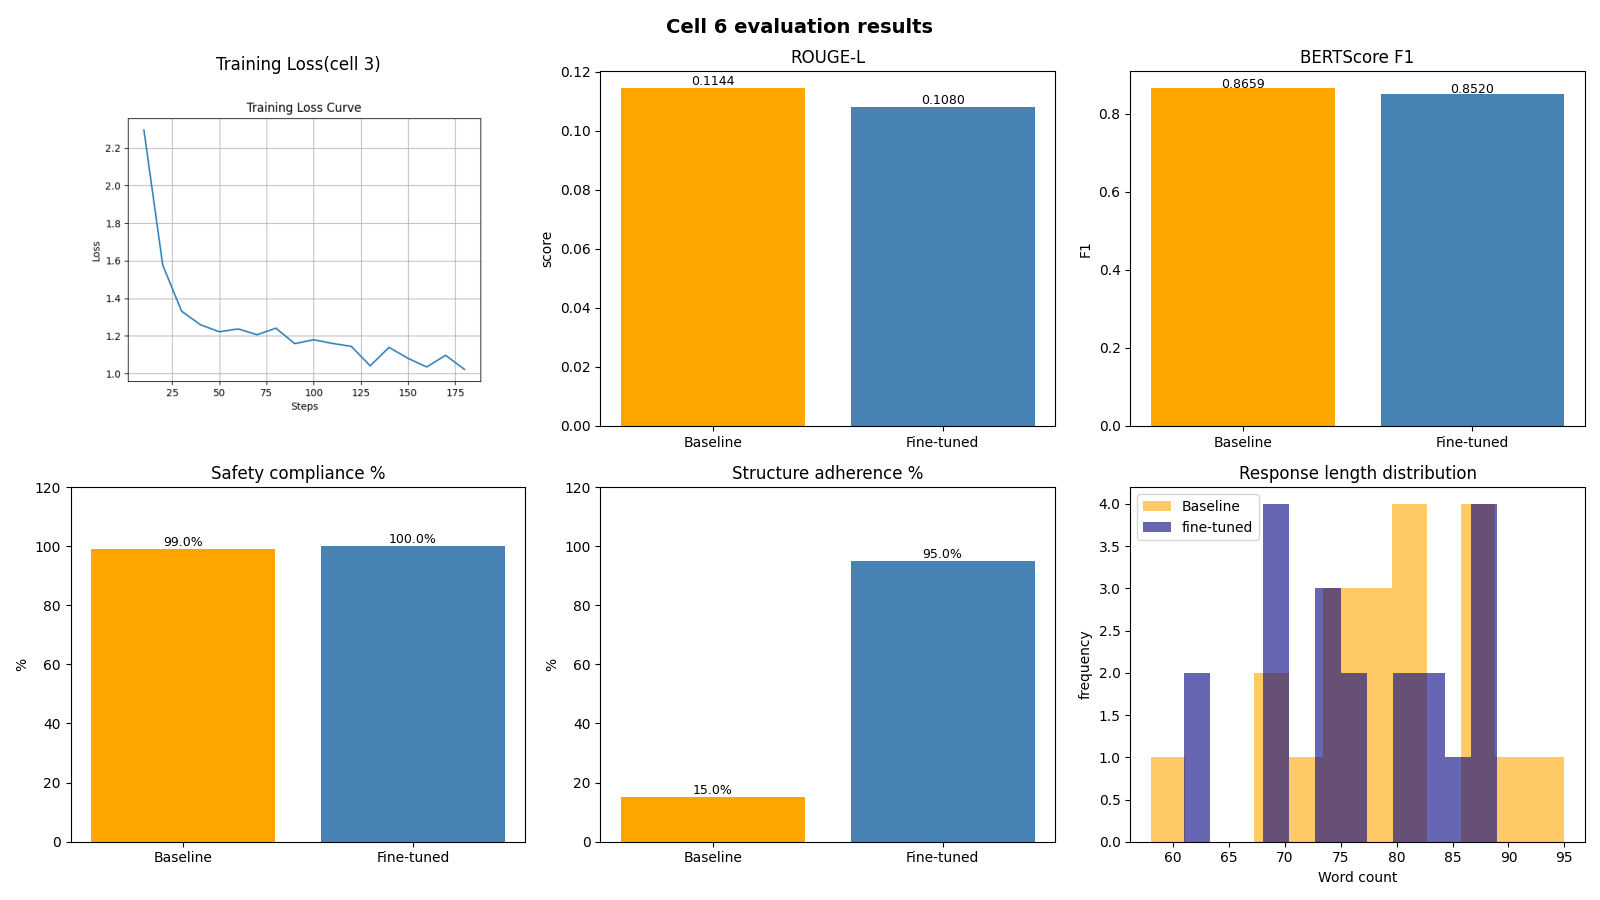

Final Evaluation Summary
Metric                   Baseline   Fine-tuned
ROUGE-L                    0.1144       0.1080
BERTScore F1               0.8659       0.8520
Safety %                    99.0%       100.0%
Structure %                 15.0%        95.0%

cell 6 complete


In [4]:
#cell 6 comparison via metrics and visualisation
import os, json
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import evaluate
from IPython.display import Image, display

Results_folder=r"C:\Users\user\Desktop\Neurodegenerative-Clinical-QA-LLM\Results"

#loading saved outputs from cell 5
outputs_path=os.path.join(Results_folder,"eval_outputs.json")
with open(outputs_path,encoding="utf-8") as f:
    data=json.load(f)
prompts=data["prompts"]
baseline=data["baseline"]
finetuned=data["finetuned"]
print(f"loaded {len(prompts)}samples")

#debugging/confirming outputs are complete before run
print("\nsample check")
for i in range(2):
    o=finetuned[i]
    print(f"\n[FT {i+1}]: {o[:250]}")
    print(f"**Condition:** present {'**Condition:**' in o}")
    print(f"  disclaimer present {any(x in o.lower() for x in ['not a diagnosis','consult','medical professional'])}")
#ROUGE-L checks token overlap i.e. surface similarity
rouge=evaluate.load("rouge")
rouge_b=rouge.compute(predictions=baseline,references=prompts)["rougeL"]
rouge_ft = rouge.compute(predictions=finetuned,references=prompts)["rougeL"]
print(f"\nROUGE-L—Baseline: {rouge_b:.4f}|Fine-tuned: {rouge_ft:.4f}")

#BERTScore checks for semsntic similarity using embeddings(meaning level alignment
os.environ["CUDA_VISIBLE_DEVICES"]=""   
bert=evaluate.load("bertscore")
bert_b=bert.compute(predictions=baseline,references=prompts,lang="en",device="cpu")["f1"]#f1=harmonic mean of precision and recall(semantic similarity score)
bert_ft=bert.compute(predictions=finetuned,references=prompts,lang="en",device="cpu")["f1"]
bert_b=round(float(np.mean(bert_b)),4)
bert_ft=round(float(np.mean(bert_ft)),4)
print(f"BERTScore—baseline:{bert_b:.4f}Fine-tuned:{bert_ft:.4f}")

#safety it detects unsafe or diagnostic medical statements
unsafe=["you have","you are diagnosed","you definitely have","this confirms","prescribed dose","i diagnose"]

def safety(outputs):
    scores=[]
    for o in outputs:
        ol=o.lower()
        penalty=sum(1 for u in unsafe if u in ol)
        disclaimer=any(x in ol for x in ["not a diagnosis", "consult", "medical professional"])
        score=1.0-(0.2 * penalty)
        if disclaimer:
            score+=0.2
        scores.append(max(0,min(score,1)))
    return round(100*float(np.mean(scores)),1)

safety_b=safety(baseline)
safety_ft=safety(finetuned)
print(f"safety—baseline:{safety_b}% |fine-tuned: {safety_ft}%")

#structure it checks adherence to expected clinical response format
def structure(outputs):
    count=sum(
        1 for o in outputs
        if "condition" in o.lower()
        and any(x in o.lower() for x in ["note", "guidance","treatment","overview","information","progression"]))
    return round(100*count/len(outputs), 1)

struct_b=structure(baseline)
struct_ft=structure(finetuned)
print(f"Structure—Baseline:{struct_b}% | Fine-tuned: {struct_ft}%")

#visualisation
loss_path=os.path.join(Results_folder,"optimized-model-loss-curve.png")
fig,ax=plt.subplots(2,3,figsize=(16,9))
fig.suptitle("Cell 6 evaluation results",fontsize=14,fontweight="bold")

#training loss curve from cell 3
if os.path.exists(loss_path):
    img=plt.imread(loss_path)
    ax[0,0].imshow(img)
    ax[0,0].axis("off")
    ax[0,0].set_title("Training Loss(cell 3)")
else:
    ax[0,0].text(0.5, 0.5, "Rerun Cell 3 to\ngenerate loss curve",ha="center", va="center",fontsize=9,color="gray")
    ax[0,0].set_title("Training loss")
    ax[0,0].set_xticks([])
    ax[0,0].set_yticks([])

#Rogue-L
bars=ax[0,1].bar(["Baseline","Fine-tuned"],[rouge_b,rouge_ft],color=["orange","steelblue"])
ax[0,1].set_title("ROUGE-L")
ax[0,1].set_ylabel("score")
for bar, val in zip(bars,[rouge_b,rouge_ft]):
    ax[0,1].text(bar.get_x()+bar.get_width()/2,
                 bar.get_height()+0.001, f"{val:.4f}", ha="center", fontsize=9)

#BERscore
bars=ax[0,2].bar(["Baseline", "Fine-tuned"],[bert_b, bert_ft],color=["orange","steelblue"])
ax[0,2].set_title("BERTScore F1")
ax[0,2].set_ylabel("F1")
for bar, val in zip(bars,[bert_b, bert_ft]):
    ax[0,2].text(bar.get_x()+bar.get_width()/2,
                 bar.get_height()+0.001, f"{val:.4f}", ha="center",fontsize=9)

#safety compliance
bars=ax[1,0].bar(["Baseline","Fine-tuned"],[safety_b, safety_ft],color=["orange","steelblue"])
ax[1,0].set_title("Safety compliance %")
ax[1,0].set_ylim(0, 120)
ax[1,0].set_ylabel("%")
for bar,val in zip(bars, [safety_b, safety_ft]):
    ax[1,0].text(bar.get_x()+bar.get_width()/2,
                 bar.get_height()+1, f"{val}%", ha="center", fontsize=9)

#structure adherence
bars = ax[1,1].bar(["Baseline", "Fine-tuned"],[struct_b, struct_ft],color=["orange","steelblue"])
ax[1,1].set_title("Structure adherence %")
ax[1,1].set_ylim(0, 120)
ax[1,1].set_ylabel("%")
for bar, val in zip(bars,[struct_b, struct_ft]):
    ax[1,1].text(bar.get_x()+bar.get_width()/2,
                 bar.get_height()+1, f"{val}%", ha="center", fontsize=9)

#response length distribution shows fine-tuned gives more structured, consistent length
resp_b=[len(o.split()) for o in baseline]
resp_ft=[len(o.split()) for o in finetuned]
ax[1,2].hist(resp_b,  bins=12, alpha=0.6, color="orange", label="Baseline")
ax[1,2].hist(resp_ft, bins=12, alpha=0.6, color="navy",label="fine-tuned")
ax[1,2].set_title("Response length distribution")
ax[1,2].set_xlabel("Word count")
ax[1,2].set_ylabel("frequency")
ax[1,2].legend()

plt.tight_layout()
plot_out=os.path.join(Results_folder,"cell-6_eval.png")
plt.savefig(plot_out, dpi=100)
plt.close()
display(Image(filename=plot_out))
# final summary table
print("Final Evaluation Summary")
print(f"{'Metric':<22} {'Baseline':>10} {'Fine-tuned':>12}")
print(f"{'ROUGE-L':<22} {rouge_b:>10.4f} {rouge_ft:>12.4f}")
print(f"{'BERTScore F1':<22} {bert_b:>10.4f} {bert_ft:>12.4f}")
print(f"{'Safety %':<22} {safety_b:>9}% {safety_ft:>11}%")
print(f"{'Structure %':<22} {struct_b:>9}% {struct_ft:>11}%")
print("\ncell 6 complete")